In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [5]:
ethiopia = pd.read_csv("../dataset/ethiopia_clean.csv")
kenya = pd.read_csv("../dataset/kenya_clean.csv")
nigeria = pd.read_csv("../dataset/nigeria_clean.csv")
sudan = pd.read_csv("../dataset/sudan_clean.csv")
tanzania = pd.read_csv("../dataset/tanzania_clean.csv")


Adding Column

In [6]:
ethiopia["Country"] = "Ethiopia"
kenya["Country"] = "Kenya"
nigeria["Country"] = "Nigeria"
sudan["Country"] = "Sudan"
tanzania["Country"] = "Tanzania"

In [7]:
df = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania])

Temperature trend comparision

In [8]:
monthly_temp = df.groupby(["Month", "Country"])["T2M"].mean().unstack()

In [10]:
df["Date"] = pd.to_datetime(df["Date"])
df["Month"] = df["Date"].dt.to_period('M')
df["Year"] = df["Date"].dt.year

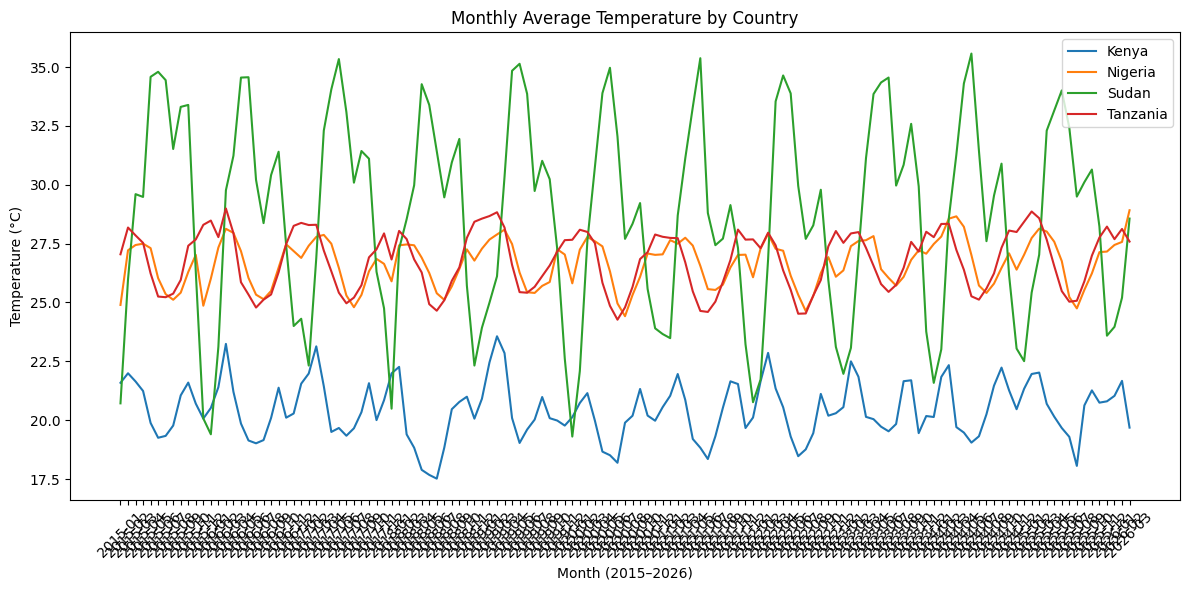

In [16]:
monthly_temp = df.groupby(['Country', 'Month'])['T2M'].mean().reset_index()

plt.figure(figsize=(12,6))

for country in monthly_temp['Country'].unique():
    subset = monthly_temp[monthly_temp['Country'] == country]
    plt.plot(subset['Month'].astype(str), subset['T2M'], label=country)

plt.xticks(rotation=45)
plt.xlabel("Month (2015–2026)")
plt.ylabel("Temperature (°C)")
plt.title("Monthly Average Temperature by Country")
plt.legend()
plt.tight_layout()
plt.show()

# Monthly Average temperature comparision analysis result
Sudan shows the highest temperature volatility, peaking sharply around mid-year (≈34–35°C) before dropping significantly toward the end of the year.
In contrast, Ethiopia remains the coolest and most stable overall, staying roughly in the mid-teens with only mild fluctuations.
Nigeria and Tanzania sit in the mid-to-high range (≈25–28°C) with relatively smooth seasonal changes, while Kenya stays consistently cooler (≈19–22°C) with a slight dip around mid-year.
Overall, most countries show a common mid-year temperature dip or shift, suggesting a shared seasonal pattern, but Sudan stands out as the most extreme and variable case.

In [18]:
summary = df.groupby("Country")["T2M"].agg(["mean", "median", "std"])
summary

,mean,median,std
Country,,,
Ethiopia,16.069557,16.04,1.897073
Kenya,20.427811,20.36,1.440936
Nigeria,26.657275,26.82,1.123251
Sudan,28.759878,29.16,4.681542
Tanzania,26.802238,26.99,1.325497


<Figure size 1000x600 with 0 Axes>

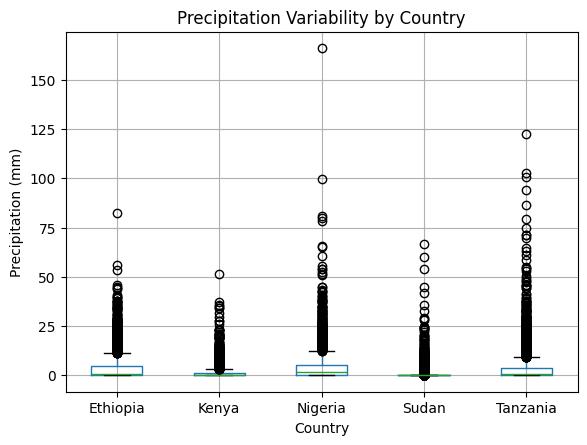

In [19]:
plt.figure(figsize=(10,6))
df.boxplot(column="PRECTOTCORR", by="Country")
plt.title("Precipitation Variability by Country")
plt.suptitle("")
plt.xlabel("Country")
plt.ylabel("Precipitation (mm)")
plt.show()

precipitation Summary Table

In [20]:
precip_summary = df.groupby("Country")["PRECTOTCORR"].agg(["mean", "median", "std"])
precip_summary

,mean,median,std
Country,,,
Ethiopia,3.634680,0.82,6.289571
Kenya,1.468520,0.38,3.180533
Nigeria,4.214940,1.84,7.267329
Sudan,0.644032,0.00,3.058028
Tanzania,3.739403,0.64,8.004735


In [37]:
heat_counts = df.groupby(['Country','Year']).apply(
    lambda x: (x['T2M_MAX'] > 35).sum()
).reset_index(name='heat_days')

In [28]:
df['dry'] = df['PRECTOTCORR'] < 1

dry_counts = df.groupby(['Country','Year'])['dry'] \
    .sum() \
    .reset_index(name='dry_days')

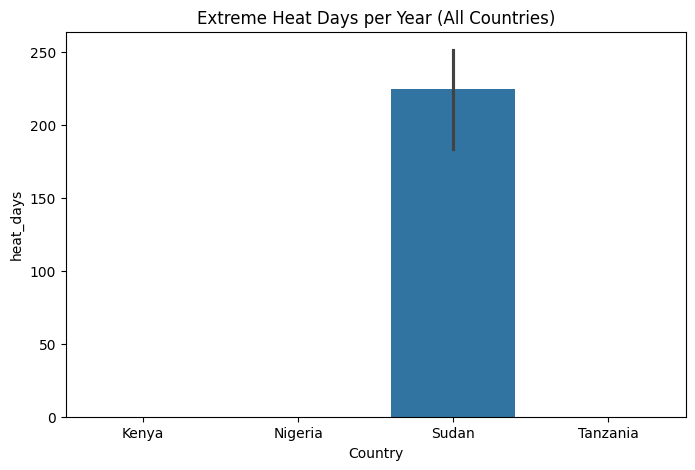

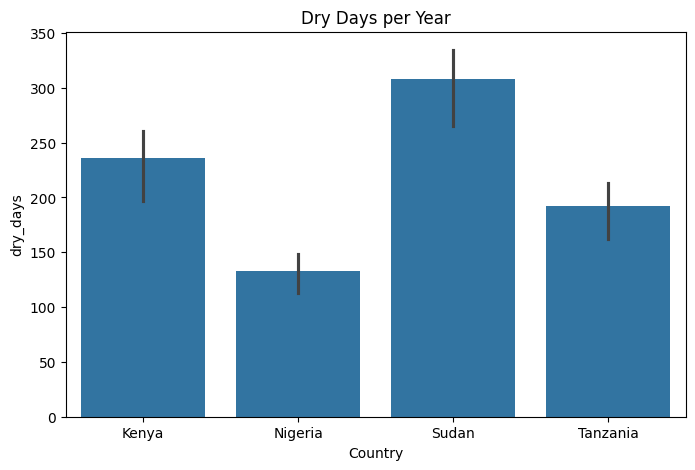

In [38]:
plt.figure(figsize=(8,5))
sns.barplot(data=heat_counts, x='Country', y='heat_days')
plt.title("Extreme Heat Days per Year (All Countries)")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=dry_counts, x='Country', y='dry_days')
plt.title("Dry Days per Year")
plt.show()

In [39]:
from scipy.stats import f_oneway

groups = [group['T2M'].values for _, group in df.groupby('Country')]
stat, p = f_oneway(*groups)

print("P-value:", p)

P-value: 0.0


the differences in temperature across countries are statistically significant.

In [41]:
ranking = pd.DataFrame()

ranking['temp_mean'] = summary['mean']
ranking['temp_std'] = summary['std']
ranking['precip_std'] = precip_summary['std']
ranking['heat_days'] = heat_counts.groupby('Country')['heat_days'].mean()
ranking['dry_days'] = dry_counts.groupby('Country')['dry_days'].mean()

# Normalize
ranking = (ranking - ranking.min()) / (ranking.max() - ranking.min())

ranking['vulnerability_score'] = ranking.sum(axis=1)

ranking = ranking.sort_values('vulnerability_score', ascending=False)
ranking

,temp_mean,temp_std,precip_std,heat_days,dry_days,vulnerability_score
Country,,,,,,
Sudan,1.000000,1.000000,0.000000,1.0,1.000000,4.000000
Tanzania,0.845738,0.056838,1.000000,0.0,0.337458,2.240034
Nigeria,0.834314,0.000000,0.850930,0.0,0.000000,1.685244
Kenya,0.343431,0.089280,0.024765,0.0,0.588291,1.045768
Ethiopia,0.000000,0.217470,0.653272,NaN,NaN,0.870742
